In [ ]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "DesyneMartinez"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW1"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/DesyneMartinez/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/DesyneMartinez/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW1


# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment

The objective for this experiment is to determine if aging time for India Pale Ale between 3-5 weeks affects the international bitterness units of the beer.

**Question 2.** Specify the outcome variable

The outcome variable is IBU (International Bitterness Units of the beer).

**Question 3.** Specify the independent variable. What are some possible lurking variables?

The independent variable (IV) is weeks the categorical ordinal variable.

Lurking Variables: There could be a lurking variable if their are different  brewery scientists using the spectrophotometer with different levels of experience and possibly the sizes of the cuvettes the scientists use.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

A CRD would be the most plausible here because we have three mutually exclusive treatments we'd like to compare and no other knowable sources of variation from lurking variables. We are randomly assigning the aging beer split between 3, 4 and 5 weeks to three tanks without many other sources of variation that we would need to control for in a more complex design.

**Question 5.** State the null and alternative hypotheses for this experiment.


$$ \begin{align}
H_0&: \text{Mean IBU between the aging time for IPA is the same} \\
H_1&: \text{Mean IBU between the aging time for IPA is different}
\end{align}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?

By looking at the results of the code below the numerical summaries between the different aging times for the IPA suggest that average IBU is different depending on the aging times. This is also visualized in the boxplots which show a clear difference between IPA aged for 3 weeks and 5 weeks. These summaries and visualizations strongly support the Alternative hypothesis.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weeks   30 non-null     object 
 1   IBU     30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
           mean       std
Weeks                    
3 Weeks  49.216  8.300656
4 Weeks  62.751  8.250384
5 Weeks  69.725  5.631258


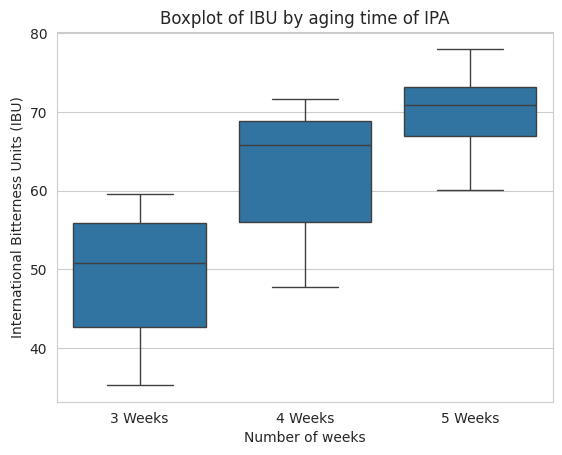

In [3]:
import pandas as pd
## Import the IPA dataset ##

ipa = pd.read_excel("IPA.xlsx")

## Data Integrity check with .info ##

ipa.info()

## Data Integrity check with .head

ipa.head()

## Data Integrity check with .describe

ipa.describe()



## Import Necessary Packages to Perform Exploratory Analysis ##
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Calculate Group Means and Standard Deviations ##

summary_stats = ipa.groupby('Weeks')['IBU'].agg(['mean','std'])

print(summary_stats)

## Generate Boxplots for Visual Comparison ##

## Set a nice minimal style for plot ##

sns.set_style("whitegrid")

## Create boxplot using seaborn ##

sns.boxplot(x="Weeks",y="IBU",data=ipa)

## Add Title and Labels using matplotlib ##

plt.title("Boxplot of IBU by aging time of IPA", loc='center')
plt.xlabel("Number of weeks")
plt.ylabel("International Bitterness Units (IBU)")
plt.show()


**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.